# Equations of state and Delta-value comparisons

This notebook follows ASE's [introductory equation-of-state example](https://docs.ase-lib.org/examples_generated/03-tutorials/eos_01.html) and [Delta-values tutorial](https://docs.ase-lib.org/examples_generated/03-tutorials/eos_delta_values.html). It first fits an energy-volume curve for FCC silver, then compares equilibrium properties obtained with EMT against experimental and WIEN2k reference data.

> **Path convention:** the notebook is intended to run from `official_tutorials_advanced`, so generated trajectories, tables, and figures are written to `../files/advanced/tutorial_02`.

In [1]:
import numpy as np

from ase import Atoms
from ase.calculators.emt import EMT
from ase.eos import EquationOfState
from ase.io import read
from ase.io.trajectory import Trajectory
from ase.units import kJ

## Sampling an equation of state for FCC Ag

An equation of state (EOS) describes how a solid's energy changes with volume. The code below constructs a one-atom primitive FCC Ag cell manually. The approximate conventional lattice constant is $a = 4.0$ Å and $b = a/2$ defines the off-diagonal components of the primitive-cell vectors. Periodic boundary conditions make this single atom represent the infinite crystal, while EMT supplies a fast model energy.

The cell is scaled by five linear factors $x$ between 0.95 and 1.05. Because all three cell vectors are scaled, each volume changes as $x^3$. `scale_atoms=True` preserves fractional atomic coordinates. Calling `get_potential_energy()` before writing ensures that the energy is stored with every configuration in `intro_Ag.traj`.

In [2]:
a = 4.0  # approximate lattice constant
b = a / 2
ag = Atoms(
    'Ag', cell=[(0, b, b), (b, 0, b), (b, b, 0)], pbc=1, calculator=EMT()
)  # use EMT potential
cell = ag.get_cell()
traj = Trajectory('../files/advanced/tutorial_02/intro_Ag.traj', 'w')
for x in np.linspace(0.95, 1.05, 5):
    ag.set_cell(cell * x, scale_atoms=True)
    ag.get_potential_energy()
    traj.write(ag)

### Fitting the equilibrium properties

The trajectory selector `@0:5` reads the first five configurations. Their cell volumes are measured in Å$^3$ and their EMT potential energies in eV. `EquationOfState.fit()` fits the sampled $E(V)$ data and returns the equilibrium volume $V_0$, the minimum energy $E_0$, and the bulk modulus $B$. Thermodynamically,

$$
P(V) = -\frac{dE}{dV},
$$

and

$$
B = -V\frac{dP}{dV} = V\frac{d^2E}{dV^2}.
$$

ASE returns $B$ in eV/Å$^3$; `B / kJ * 1.0e24` converts it to GPa. The saved result gives $V_0 = 16.781$ Å$^3$ for the primitive cell and $B = 100.142$ GPa. The fitted $E_0$ is close to zero because of EMT's chosen energy reference, not because the crystal has no binding energy. The fit is also saved as `intro_Ag-eos.png`.

100.14189241973286 GPa


<Axes: title={'center': 'sj: E: -0.000 eV, V: 16.781 Å$^3$, B: 100.142 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

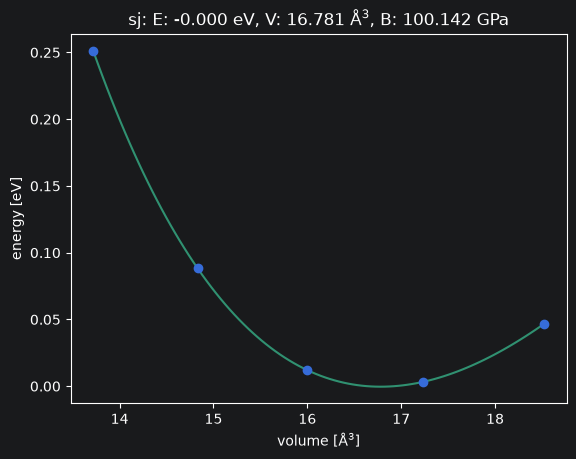

In [3]:
configs = read('../files/advanced/tutorial_02/intro_Ag.traj@0:5')  # read 5 configurations
# Extract volumes and energies:
volumes = [ag.get_volume() for ag in configs]
energies = [ag.get_potential_energy() for ag in configs]
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()
print(B / kJ * 1.0e24, 'GPa')
eos.plot('../files/advanced/tutorial_02/intro_Ag-eos.png')

### Inspecting the Ag trajectory

The five strained cells can be browsed with ASE's GUI. From the repository root, run:

```bash
ase gui files/advanced/tutorial_02/intro_Ag.traj
```

In the GUI, **Tools → Bulk modulus** provides a quick visual EOS inspection. This requires a Python installation with Tk support; the notebook fit itself does not depend on the GUI.

## Comparing EOS parameters with Delta values

The second workflow extends the EOS analysis to Al, Ni, Cu, Pd, Ag, Pt, and Au. For each element it compares EMT with experimental and WIEN2k entries from ASE's `dcdft` collection. The fitted quantities are the equilibrium atomic volume $V_0$, bulk modulus $B$, and pressure derivative $B' = dB/dP$. Here $V_0$ is reported in Å$^3$/atom, $B$ in GPa after conversion, and $B'$ is dimensionless.

The Delta value condenses the separation between two EOS energy curves into one root-mean-square energy difference over a specified volume interval:

$$
\Delta = \sqrt{\frac{1}{V_b - V_a}\int_{V_a}^{V_b}[E_1(V)-E_2(V)]^2\,dV}.
$$

A smaller $\Delta$ means that the two fitted energy-volume curves agree more closely over that interval. It is not, by itself, a general accuracy score or an experimental uncertainty.

### Generating EMT energy-volume data

For every element, the next cell creates seven structures whose volumes span 94% to 106% of the reference volume in 2% increments. The factor $(s/100)^{1/3}$ is applied to each cell vector, so the resulting volume factor is exactly $s/100$. Each EMT energy is evaluated and stored in an element-specific trajectory for later fitting.

In [4]:
from pathlib import Path

from ase.calculators.emt import EMT
from ase.collections import dcdft
from ase.io import Trajectory

trajfiles = []

for symbol in ['Al', 'Ni', 'Cu', 'Pd', 'Ag', 'Pt', 'Au']:
    trajfile = Path(f'../files/advanced/tutorial_02/{symbol}.traj')
    with Trajectory(trajfile, 'w') as traj:
        for s in range(94, 108, 2):
            atoms = dcdft[symbol]
            atoms.set_cell(atoms.cell * (s / 100) ** (1 / 3), scale_atoms=True)
            atoms.calc = EMT()
            atoms.get_potential_energy()
            traj.write(atoms)
    trajfiles.append(trajfile)

### Fitting Birch-Murnaghan parameters

The fit normalizes every volume and energy by the number of atoms, making the results comparable across differently sized reference cells. A Birch-Murnaghan EOS is then fitted to each element. ASE stores its parameters as $(E_0, B, B', V_0)$; the helper returns them as $(E_0, V_0, B, B')$ before collecting the EMT values in `fit.json`.

The displayed integer `963` is the number of characters written by `Path.write_text()`. It confirms that text was written; it is not a fitted physical quantity.

In [5]:
import json

from ase.eos import EquationOfState as EOS
from ase.io import read


def fit(symbol: str) -> tuple[float, float, float, float]:
    V = []
    E = []
    for atoms in read(f'../files/advanced/tutorial_02/{symbol}.traj@:'):
        V.append(atoms.get_volume() / len(atoms))
        E.append(atoms.get_potential_energy() / len(atoms))

    eos = EOS(V, E, 'birchmurnaghan')
    eos.fit(warn=False)
    e0, B, Bp, v0 = eos.eos_parameters
    return e0, v0, B, Bp


data = {}  # Dict[str, Dict[str, float]]
for path in trajfiles:
    symbol = path.stem
    e0, v0, B, Bp = fit(symbol)
    data[symbol] = {
        'emt_energy': e0,
        'emt_volume': v0,
        'emt_B': B,
        'emt_Bp': Bp,
    }

Path('../files/advanced/tutorial_02/fit.json').write_text(json.dumps(data))

963

### Inspecting the Pt fit

Platinum provides a representative visual check. The trajectory is read back, converted to per-atom volumes and energies, and fitted again with the Birch-Murnaghan form. The plot overlays the fitted curve and sampled points over 14–16 Å$^3$/atom; the title generated by `eos.plot()` reports the fitted $V_0$, $E_0$, and $B$. A smooth minimum surrounded by sampled volumes indicates that the equilibrium point is interpolated rather than extrapolated.

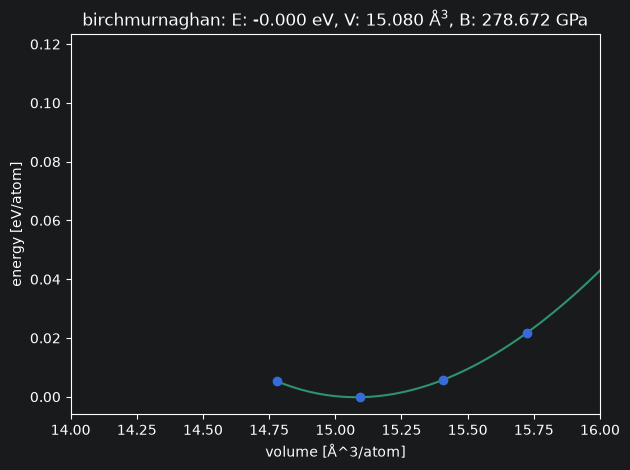

In [6]:
import matplotlib.pyplot as plt

V, E = [], []
for atoms in read('../files/advanced/tutorial_02/Pt.traj@:'):
    V.append(atoms.get_volume() / len(atoms))
    E.append(atoms.get_potential_energy() / len(atoms))

eos = EOS(V, E, 'birchmurnaghan')
eos.fit(warn=False)

fig = plt.figure()
ax = fig.gca()
eos.plot(ax=ax)  # draw onto the current axes
ax.set_xlim(14.0, 16.0)
ax.set_xlabel('volume [Å^3/atom]')
ax.set_ylabel('energy [eV/atom]')
plt.tight_layout()

### Calculating one Pt Delta value

`delta()` compares two EOS parameter sets supplied as $(V_0, B, B')$. The first set is the EMT Pt fit and the second is the WIEN2k reference. Because ASE's EOS routines use eV/Å$^3$ internally, each reference bulk modulus in GPa is converted with `1e-24 * kJ`.

The result is $0.03205$ eV/atom, or approximately $32.05$ meV/atom. This value measures the separation of these two fitted Pt energy-volume curves over the Delta comparison interval.

In [7]:
from ase.units import kJ
from ase.utils.deltacodesdft import delta

delta(15.08, 278.67 * 1e-24 * kJ, 5.31, 15.64, 248.71 * 1e-24 * kJ, 5.46)

np.float64(0.03205389052984122)

### Writing comparison tables and a Pt diagnostic plot

The final analysis combines the EMT fits with experimental and WIEN2k values from `dcdft`. Reference bulk moduli are first converted from GPa to ASE's internal eV/Å$^3$ units so all three EOS parameter sets can be passed consistently to `delta()`. The generated files are:

- `volume.csv`: equilibrium volume in Å$^3$/atom;
- `B.csv`: bulk modulus in GPa;
- `Bp.csv`: dimensionless pressure derivative $B'$;
- `delta.csv`: pairwise Delta values in meV/atom; and
- `Pt.png`: the EMT, experimental, and WIEN2k Birch-Murnaghan curves together with the sampled EMT points.

> **Rerun note:** `dcdft_dct = dcdft.data[symbol]` refers directly to the collection's stored dictionary, and the following `*=` operations modify its bulk moduli in place. Re-running this cell in the same kernel would apply the unit conversion again. Use a fresh kernel before re-running the complete workflow.

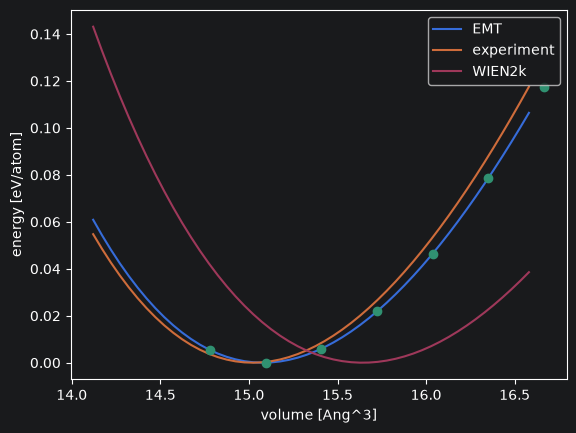

In [8]:
from ase.eos import birchmurnaghan

# Read EMT data:
data = json.loads(Path('../files/advanced/tutorial_02/fit.json').read_text())
# Insert values from experiment and WIEN2k:
for symbol in data:
    dcdft_dct = dcdft.data[symbol]
    dcdft_dct['exp_B'] *= 1e-24 * kJ
    dcdft_dct['wien2k_B'] *= 1e-24 * kJ
    data[symbol].update(dcdft_dct)

for name in ['volume', 'B', 'Bp']:
    with open('../files/advanced/tutorial_02/' + name + '.csv', 'w') as fd:
        print('# symbol, emt, exp, wien2k', file=fd)
        for symbol, dct in data.items():
            values = [
                dct[code + '_' + name] for code in ['emt', 'exp', 'wien2k']
            ]
            if name == 'B':
                values = [val * 1e24 / kJ for val in values]
            print(
                f'{symbol},',
                ', '.join(f'{value:.2f}' for value in values),
                file=fd,
            )

with open('../files/advanced/tutorial_02/delta.csv', 'w') as fd:
    print('# symbol, emt-exp, emt-wien2k, exp-wien2k', file=fd)
    for symbol, dct in data.items():
        # Get v0, B, Bp:
        emt, exp, wien2k = (
            (dct[code + '_volume'], dct[code + '_B'], dct[code + '_Bp'])
            for code in ['emt', 'exp', 'wien2k']
        )
        print(
            f'{symbol}, {delta(*emt, *exp) * 1000:.1f}, '
            f'{delta(*emt, *wien2k) * 1000:.1f}, '
            f'{delta(*exp, *wien2k) * 1000:.1f}',
            file=fd,
        )

        if symbol == 'Pt':
            va = min(emt[0], exp[0], wien2k[0])
            vb = max(emt[0], exp[0], wien2k[0])
            v = np.linspace(0.94 * va, 1.06 * vb)
            for (v0, B, Bp), code in [
                (emt, 'EMT'),
                (exp, 'experiment'),
                (wien2k, 'WIEN2k'),
            ]:
                plt.plot(v, birchmurnaghan(v, 0.0, B, Bp, v0), label=code)
            e0 = dct['emt_energy']
            V = []
            E = []
            for atoms in read('../files/advanced/tutorial_02/Pt.traj@:'):
                V.append(atoms.get_volume() / len(atoms))
                E.append(atoms.get_potential_energy() / len(atoms) - e0)
            plt.plot(V, E, 'o')
            plt.legend()
            plt.xlabel('volume [Ang^3]')
            plt.ylabel('energy [eV/atom]')
            plt.savefig('../files/advanced/tutorial_02/Pt.png')

## Takeaways and possible extensions

- EOS fitting turns a set of strained-cell energies into $V_0$, $E_0$, $B$, and $B'$. Reliable fits require volumes on both sides of the energy minimum.
- Normalize volume and energy per atom before comparing cells of different sizes, and keep bulk-modulus units consistent.
- The Delta value compares complete EOS curves, so it contains more information than comparing equilibrium volumes or bulk moduli separately. A lower value indicates closer curves only within the chosen comparison protocol.
- EMT is useful for learning and inexpensive tests, but agreement here should not be generalized to elements or bonding environments outside the model's scope.
- Useful extensions include increasing the number of sampled volumes, comparing alternative EOS forms, checking how the fitted parameters converge with sampling range, or repeating the workflow with a first-principles calculator.